This notebook scrapes data from yfinance, using the NumPy, pandas, and scipy libraries computes descriptive statistics and the four moments.

We begin by using yf.download to call the adjusted closing prices of the given securities. We use SPY instead of ^GSPC because SPY is actually tradeable.


In [1]:
import pandas as pd
import numpy as np
from scipy.stats import skew
from scipy.stats import kurtosis
from scipy.stats import norm
import matplotlib.pyplot as plt

## Return Definitions
Simple returns are intuitive and used for interpretation and reporting.<br>

Log returns are additive over time and more convenient for modelling and statistical analysis.
Both are computed here to compare their behaviour on daily equity data.

In [2]:
#import yfinance for data
import yfinance as yf
secs = ['AAPL', 'SAIL.NS', 'MSFT', 'RELIANCE.NS', 'SPY'] #define securities in a list
data = yf.download(secs, start='2016-01-01', end='2026-01-01', auto_adjust=False) #download data within time frame, auto_adjust false
#means adj close is available separately, otherwise OHLC is adjusted by default
adj_close = data['Adj Close'].dropna() #defining adjusted close and dropna removes N/A entries

returns = adj_close.pct_change().dropna() #computing returns cause prices are usless and dropna removes N/A entries
log_returns = np.log(adj_close).diff().dropna() #computing log returns
print(returns.head())
print(log_returns.head())

[*********************100%***********************]  5 of 5 completed

Ticker          AAPL      MSFT  RELIANCE.NS   SAIL.NS       SPY
Date                                                           
2016-01-05 -0.025059  0.004562     0.009896  0.064718  0.001691
2016-01-06 -0.019570 -0.018165     0.026911 -0.019608 -0.012614
2016-01-07 -0.042204 -0.034783    -0.018359 -0.069000 -0.023991
2016-01-08  0.005287  0.003067     0.012337  0.018260 -0.010977
2016-01-11  0.016192 -0.000573     0.025201 -0.020042  0.000990
Ticker          AAPL      MSFT  RELIANCE.NS   SAIL.NS       SPY
Date                                                           
2016-01-05 -0.025378  0.004552     0.009848  0.062710  0.001690
2016-01-06 -0.019764 -0.018332     0.026556 -0.019803 -0.012695
2016-01-07 -0.043120 -0.035402    -0.018530 -0.071496 -0.024284
2016-01-08  0.005273  0.003062     0.012261  0.018095 -0.011038
2016-01-11  0.016062 -0.000573     0.024889 -0.020246  0.000989


From the prices, we compute simple returns. Analysis of returns leads to data that can be studied. Direct analysis of prices would lead to nonsensical results. We compute descriptive statistics for each asset seprately.

In [3]:
# Now calculate statistics PER ASSET (column-wise).
print("=== Means (Annualised Daily Return) ===")
print(returns.mean()*252)
print(log_returns.mean()*252)
mean = returns.mean()*252
mean2 = log_returns.mean()*252
print("\n=== Standard Deviation (Annualised Daily Volatility) ===") # \n is like text break
std = returns.std()*np.sqrt(252)
std2 = log_returns.std()*np.sqrt(252)
print(returns.std()*np.sqrt(252))
risk_free_rate = 0.02  # 2% annual

# Skew and Kurtosis
print("\n=== Skewness ===")
print(returns.skew())
print("\n=== Kurtosis (Excess) ===")
print(returns.kurtosis())

=== Means (Annualised Daily Return) ===
Ticker
AAPL           0.300898
MSFT           0.280901
RELIANCE.NS    0.246470
SAIL.NS        0.238162
SPY            0.162763
dtype: float64
Ticker
AAPL           0.256908
MSFT           0.243510
RELIANCE.NS    0.209247
SAIL.NS        0.137107
SPY            0.146175
dtype: float64

=== Standard Deviation (Annualised Daily Volatility) ===
Ticker
AAPL           0.296413
MSFT           0.273108
RELIANCE.NS    0.273140
SAIL.NS        0.449830
SPY            0.181682
dtype: float64

=== Skewness ===
Ticker
AAPL           0.128314
MSFT           0.047962
RELIANCE.NS    0.416789
SAIL.NS        0.145827
SPY           -0.314040
dtype: float64

=== Kurtosis (Excess) ===
Ticker
AAPL            6.649528
MSFT            7.818257
RELIANCE.NS     9.106381
SAIL.NS         3.878065
SPY            14.681546
dtype: float64


Plotting Sharpe ratios, means, and standard deviations

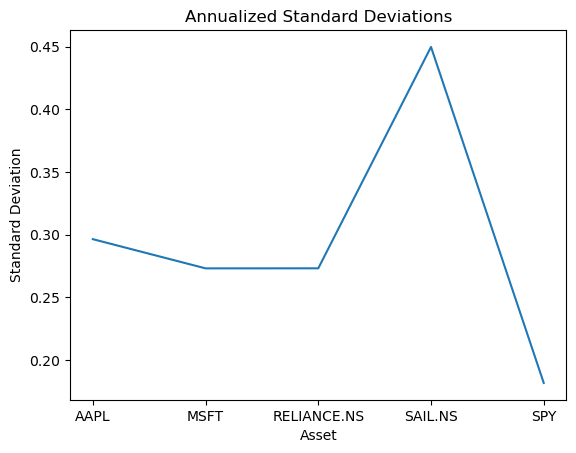

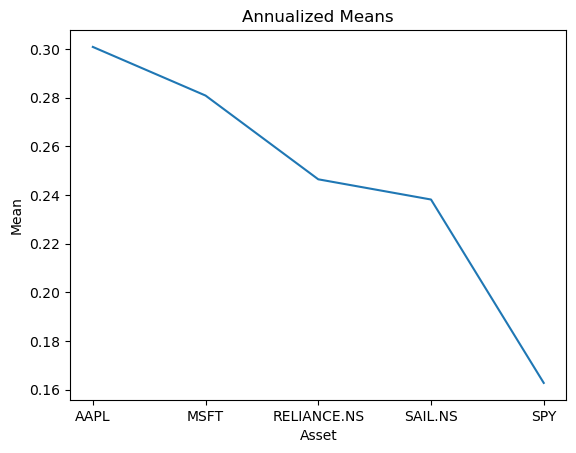

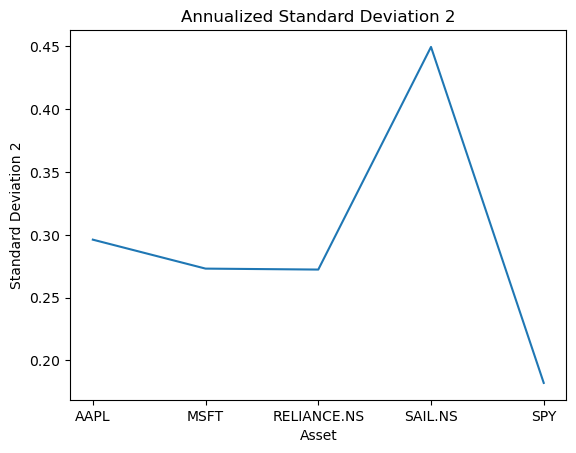

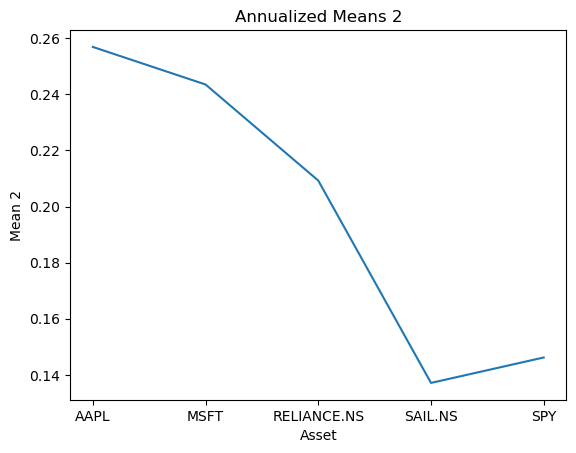

In [4]:
plt.plot(std)
plt.title('Annualized Standard Deviations')
plt.xlabel('Asset')
plt.ylabel('Standard Deviation')
plt.show()

plt.plot(mean)
plt.title('Annualized Means')
plt.xlabel('Asset')
plt.ylabel('Mean')
plt.show()

plt.plot(std2)
plt.title('Annualized Standard Deviation 2')
plt.xlabel('Asset')
plt.ylabel('Standard Deviation 2')
plt.show()

plt.plot(mean2)
plt.title('Annualized Means 2')
plt.xlabel('Asset')
plt.ylabel('Mean 2')
plt.show()

Now, we use a correlation matrix to study dependencies across our porfolio. First, we compute a returns correlation matrix. Then we compute annualised volatilities and finally, annualised covariance matrix.

In [5]:
# Correlation matrix (from daily returns)
corr_matrix = returns.corr()
cr_mat = log_returns.corr()
print("Correlation Matrix (Daily):")
print(corr_matrix.round(3))
print("Correlation Matrix Log Returns (Daily):")
print(cr_mat.round(3))

Correlation Matrix (Daily):
Ticker        AAPL   MSFT  RELIANCE.NS  SAIL.NS    SPY
Ticker                                                
AAPL         1.000  0.660        0.112    0.123  0.741
MSFT         0.660  1.000        0.123    0.118  0.790
RELIANCE.NS  0.112  0.123        1.000    0.324  0.202
SAIL.NS      0.123  0.118        0.324    1.000  0.198
SPY          0.741  0.790        0.202    0.198  1.000
Correlation Matrix Log Returns (Daily):
Ticker        AAPL   MSFT  RELIANCE.NS  SAIL.NS    SPY
Ticker                                                
AAPL         1.000  0.662        0.115    0.124  0.742
MSFT         0.662  1.000        0.126    0.117  0.791
RELIANCE.NS  0.115  0.126        1.000    0.331  0.206
SAIL.NS      0.124  0.117        0.331    1.000  0.200
SPY          0.742  0.791        0.206    0.200  1.000


In [6]:
# Calculate annualized volatilities
annual_vols = returns.std() * np.sqrt(252)  # This is your 'vols'
annual_vols2 = log_returns.std() * np.sqrt(252)  # This is your 'vols'

# Correlation matrix (from daily returns)
corr_matrix = returns.corr()
corr_matrix2 = log_returns.corr()

# Build the annualized covariance matrix
# Σ_annual = Corr * (σ_i * σ_j) for all i,j
cov_matrix_annual = corr_matrix * np.outer(annual_vols, annual_vols) #computes the outer product of two vectors
cov_matrix_annual2 = corr_matrix2 * np.outer(annual_vols2, annual_vols2) #

In [7]:
# Annualized covariance matrix: Corr * (std_i * std_j)
# We already have annualized volatilities (std_annual)
std_annual = returns.std() * np.sqrt(252)  # Should match your earlier numbers
std_annual

Ticker
AAPL           0.296413
MSFT           0.273108
RELIANCE.NS    0.273140
SAIL.NS        0.449830
SPY            0.181682
dtype: float64

In [8]:
std_annual2 = log_returns.std() * np.sqrt(252)  # check
std_annual2

Ticker
AAPL           0.296141
MSFT           0.273084
RELIANCE.NS    0.272327
SAIL.NS        0.449580
SPY            0.182082
dtype: float64

In [9]:
# Build the covariance matrix manually to understand it:
cov_matrix_annual = np.outer(std_annual, std_annual) * corr_matrix
cov_matrix_annual2 = np.outer(std_annual2, std_annual2) * corr_matrix2

In [10]:
print("\nAnnualized Covariance Matrix 2:")
print(pd.DataFrame(cov_matrix_annual2, index=std_annual.index, columns=std_annual.index).round(6))


Annualized Covariance Matrix 2:
Ticker           AAPL      MSFT  RELIANCE.NS   SAIL.NS       SPY
Ticker                                                          
AAPL         0.087699  0.053529     0.009302  0.016483  0.039987
MSFT         0.053529  0.074575     0.009401  0.014388  0.039328
RELIANCE.NS  0.009302  0.009401     0.074162  0.040477  0.010239
SAIL.NS      0.016483  0.014388     0.040477  0.202122  0.016381
SPY          0.039987  0.039328     0.010239  0.016381  0.033154


Calculating beta and CAPM

In [11]:
# Beta & CAPM Expected Return
market_returns = returns['SPY']
market_returns2 = log_returns['SPY']
stock_returns = returns.drop(columns=['SPY'])
stock_log_returns = log_returns.drop(columns=['SPY'])
betas = {}
for stock in stock_returns.columns:
    cov = np.cov(stock_returns[stock], market_returns)[0,1]
    beta = cov / np.var(market_returns)
    betas[stock] = beta
    # Expected Return = Rf + beta * (Market Return - Rf)
    expected_return = risk_free_rate + beta * (market_returns.mean() * 252 - risk_free_rate)
    print(f"{stock}: Beta = {beta:.3f}, Exp Return = {expected_return:.2%}")

for stck in stock_log_returns:
    cov = np.cov(stock_log_returns[stck], market_returns2)[0,1]
    beta2 = cov / np.var(market_returns2)
    betas[stck] = beta2
    # Expected Return = Rf + beta * (Market Return - Rf)
    expected_return = risk_free_rate + beta2 * (market_returns2.mean() * 252 - risk_free_rate)
    print(f"{stck}: Beta = {beta2:.3f}, Exp Return = {expected_return:.2%}")

AAPL: Beta = 1.209, Exp Return = 19.25%
MSFT: Beta = 1.188, Exp Return = 18.96%
RELIANCE.NS: Beta = 0.304, Exp Return = 6.34%
SAIL.NS: Beta = 0.492, Exp Return = 9.02%
AAPL: Beta = 1.207, Exp Return = 17.22%
MSFT: Beta = 1.187, Exp Return = 16.97%
RELIANCE.NS: Beta = 0.309, Exp Return = 5.90%
SAIL.NS: Beta = 0.494, Exp Return = 8.24%


In [12]:
# Calculate annualized volatilities
annual_vols = returns.std() * np.sqrt(252)  # This is your 'vols'

# Correlation matrix (from daily returns)
corr_matrix = returns.corr()

# Build the annualized covariance matrix
# Σ_annual = Corr * (σ_i * σ_j) for all i,j
cov_matrix_annual = corr_matrix * np.outer(annual_vols, annual_vols)
cov_matrix_annual

Ticker,AAPL,MSFT,RELIANCE.NS,SAIL.NS,SPY
Ticker,,,,,
AAPL,0.087861,0.053396,0.009072,0.016374,0.039878
MSFT,0.053396,0.074588,0.009151,0.014439,0.039199
RELIANCE.NS,0.009072,0.009151,0.074606,0.039761,0.010023
SAIL.NS,0.016374,0.014439,0.039761,0.202347,0.016222
SPY,0.039878,0.039199,0.010023,0.016222,0.033009


In [13]:
print("AAPL annual vol:", std_annual['AAPL'])           # Should be ~0.296
print("AAPL annual variance:", std_annual['AAPL']**2)   # Should be ~0.0876
print("Cov matrix diagonal:", cov_matrix_annual.loc['AAPL', 'AAPL'])  # Should match 

AAPL annual vol: 0.2964128342875248
AAPL annual variance: 0.08786056833036364
Cov matrix diagonal: 0.08786056833036364


In [14]:
# Verify shape and print a snippet
print("Covariance Matrix (annualized) shape:", cov_matrix_annual.shape)
print("\nDiagonal elements (should be variances, i.e., vol^2):")
for i, ticker in enumerate(returns.columns):
    # Use .iloc for integer-based indexing on the DataFrame
    print(f"{ticker}: {cov_matrix_annual.iloc[i, i]:.6f} ≈ {annual_vols[ticker]**2:.6f}")

Covariance Matrix (annualized) shape: (5, 5)

Diagonal elements (should be variances, i.e., vol^2):
AAPL: 0.087861 ≈ 0.087861
MSFT: 0.074588 ≈ 0.074588
RELIANCE.NS: 0.074606 ≈ 0.074606
SAIL.NS: 0.202347 ≈ 0.202347
SPY: 0.033009 ≈ 0.033009


In [15]:
# Define portfolio weights (equal-weight example)
assets = returns.columns.tolist()
weights = np.array([1/len(assets)] * len(assets))  # Equal weight

# Portfolio variance & volatility (annualized)
portfolio_variance = weights.T @ cov_matrix_annual @ weights
portfolio_vol = np.sqrt(portfolio_variance)

# Portfolio returns
portfolio_returns = returns @ weights

print(f"\nEqual-weight portfolio annual volatility: {portfolio_vol:.4f} ({portfolio_vol*100:.2f}%)")


Equal-weight portfolio annual volatility: 0.1967 (19.67%)


In [16]:
vol_values = [0.296413, 0.273108, 0.273140, 0.449830, 0.181682]
np.mean(vol_values)

0.2948346

The earlier individual volatilities were 0.2964, 0.2731, 0.2731, 0.4498, 0.1817, meaning average is 0.295, however, equal-weighted annual vol is 0.197. <br> <br> That is a 33.22% reduction in volatility. This can be expanded upon by utilising sharpe ratio for allocating weights with an ideal risk-return profile. However, this is omitted for the sake of simplicity. 

In [17]:
# Now we compute VaR on our portfolio
# Regulatory market risk frameworks commonly require 10-day risk measures
# Therefore, 1-day VaR is scaled using the square-root-of-time rule.

alpha_var = 0.95
alpha_es  = 0.975

var_1d = np.percentile(portfolio_returns, (1 - alpha_var) * 100)
var_10d_loss = -var_1d*np.sqrt(10)
es_var_threshold = np.percentile(portfolio_returns, (1 - alpha_es) * 100)
tail_returns = portfolio_returns[portfolio_returns <= es_var_threshold]
es_10d_loss = -tail_returns.mean()*np.sqrt(10)

assert var_10d_loss > 0, "VaR loss must be positive"
assert es_10d_loss > 0, "ES loss must be positive"
assert es_10d_loss >= var_10d_loss, "ES should be greater than or equal to VaR"

In [18]:
print(f"10-day {alpha_var*100: .0f}% Historical VaR: {var_10d_loss:.2%}")
print(f"10-day {alpha_es*100:.1f}% Historical ES: {es_10d_loss:.2%}")

10-day  95% Historical VaR: 5.50%
10-day 97.5% Historical ES: 11.32%


In [19]:
mu = portfolio_returns.mean()
sigma = portfolio_returns.std()
z_var = norm.ppf(1 - alpha_var)
var_parametric_10d_loss = -(mu + sigma * z_var)*np.sqrt(10)

z_es = norm.ppf(1 - alpha_es)
es_parametric_10d_loss = (mu + sigma * norm.pdf(z_es) / (1 - alpha_es))*np.sqrt(10)

assert var_parametric_10d_loss > 0, "Parametric VaR must be positive"
assert es_parametric_10d_loss > 0, "Parametric ES must be positive"
assert es_parametric_10d_loss >= var_parametric_10d_loss, "ES must be >= VaR"

In [20]:
print(f"10-day {alpha_var*100: .0f}% Parametric VaR (Normal): {var_parametric_10d_loss:.2%}")
print(f"10-day {alpha_es*100}% Parametric ES (Normal): {es_parametric_10d_loss:.2%}")

10-day  95% Parametric VaR (Normal): 6.14%
10-day 97.5% Parametric ES (Normal): 9.47%


Parametric risk measures rely on distributional assumptions and may underestimate tail risk in the presence of skewness and excess kurtosis.<br><br>
Parametric ES increases more than √T due to tail sensitivity of φ(z)/(1−α) under the normal assumption

### Time Scaling of Parametric Expected Shortfall

While VaR and ES are often approximated as scaling with √T under
Gaussian i.i.d. assumptions, parametric ES does not scale exactly
by √T.

The Expected Shortfall formula is:

ES_α = μ + σ · φ(z_α) / (1 − α)

When scaling from 1 day to T days:

μ_T = Tμ  
σ_T = √T σ

Thus:

ES_T = Tμ + √T σ · φ(z_α) / (1 − α)

Unless μ = 0, the ratio ES_T / ES_1d is not exactly √T.
At high confidence levels, the ES tail factor amplifies this effect,
causing parametric ES to grow slightly faster than √T.

This explains why 10-day parametric ES exceeds the naive √10 scaling
of the 1-day ES.